Epoch 0: Avg loss 0.3143
Epoch 10: Avg loss 0.0102
Epoch 20: Avg loss 0.0057
Epoch 30: Avg loss 0.0048
Epoch 40: Avg loss 0.0033


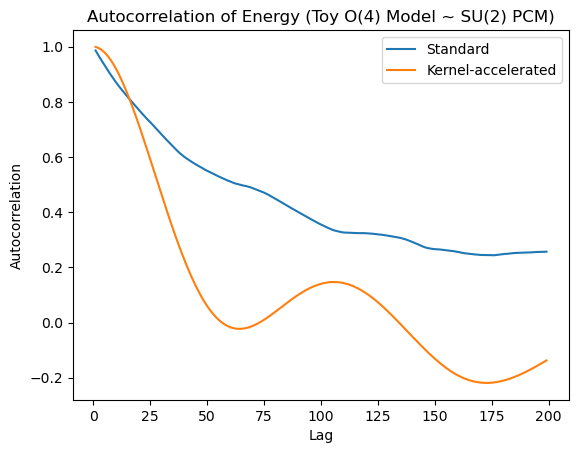

Estimated tau standard: 120.17
Estimated tau kernel: 61.43


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Kernel definition
class GoldstoneHyperHoloBlock(nn.Module):
    def __init__(self, dim=64, depth=5, alpha=1.7, slip_factor=0.15, ng_strength=0.1):
        super().__init__()
        self.depth = depth
        self.alpha = alpha
        self.proj = nn.Linear(dim, dim)
        self.slip_gen = nn.Linear(dim, dim)
        self.holo_proj = nn.Linear(dim * 2, dim * 4)
        self.inv_holo = nn.Linear(dim * 4, dim)
        self.ng_proj = nn.Linear(dim, dim)
        self.ng_strength = ng_strength
        self.slip_factor = slip_factor
        self.norm_h = nn.LayerNorm(dim)
        self.norm_out = nn.LayerNorm(dim)

    def forward(self, x, level=0, t_step=0.0):
        if level >= self.depth:
            return x

        slip = torch.tanh(self.slip_gen(x)) * self.slip_factor
        h = torch.relu(self.proj(x + slip))
        h = self.norm_h(h)

        h_child = self.forward(h, level + 1, t_step)

        concat = torch.cat([h, h_child], dim=-1)
        boundary = self.holo_proj(concat)
        resolved = self.inv_holo(boundary)
        fb = resolved * h

        vev_rand = torch.tanh(torch.randn_like(h.mean(dim=-1, keepdim=True)))
        vev = torch.norm(h, dim=-1, keepdim=True) * 0.005 * vev_rand
        h_broken = h + vev

        proj = self.ng_proj(h_broken)
        norm_hb_sq = h_broken.norm(dim=-1, keepdim=True)**2 + 1e-6
        dot = (proj * h_broken).sum(-1, keepdim=True) / norm_hb_sq
        goldstone = proj - dot * h_broken
        phase = torch.sin(t_step * 2.0 * np.pi + torch.randn_like(goldstone) * 0.2)

        h = h + self.ng_strength * goldstone * phase
        h = self.norm_h(h)

        out = x + fb + 0.05 * h_child
        mask_prob = max(0.1, 1.0 / ((level + 1) ** self.alpha))
        mask = (torch.rand_like(out) < mask_prob).float()
        out = out * mask
        out = self.norm_out(out)

        return out

class CoherenceNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.embed = nn.Linear(input_dim, hidden_dim)
        self.fractal_core = GoldstoneHyperHoloBlock(hidden_dim)
        self.head = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, steps=1):
        h = self.embed(x)
        for t in range(steps):
            h = self.fractal_core(h, t_step=t / steps)
        out = self.head(h)
        return out

# O(4) functions
def o4_energy(spins, J=1.0):
    energy = 0.0
    N = spins.shape[0]
    for i in range(N):
        for j in range(N):
            energy += np.dot(spins[i, j], spins[i, (j + 1) % N])
            energy += np.dot(spins[i, j], spins[(i + 1) % N, j])
    return -J * energy

def metropolis_step(spins, beta):
    N = spins.shape[0]
    i, j = np.random.randint(0, N, 2)
    old_s = spins[i, j].copy()
    delta = np.random.randn(4) * 0.3
    new_s = old_s + delta
    norm = np.linalg.norm(new_s)
    if norm > 0:
        new_s /= norm
    else:
        new_s = np.random.randn(4)
        new_s /= np.linalg.norm(new_s)
    dE = 0
    neigh = [(i, (j - 1) % N), (i, (j + 1) % N), ((i - 1) % N, j), ((i + 1) % N, j)]
    for ni, nj in neigh:
        dE += np.dot(new_s - old_s, spins[ni, nj])
    dE = -dE
    if dE < 0 or np.random.rand() < np.exp(-beta * dE):
        spins[i, j] = new_s
    return spins

def autocorrelation(timeseries, lag):
    mean = np.mean(timeseries)
    var = np.var(timeseries)
    if var == 0:
        return 0.0
    return np.mean((timeseries[:-lag] - mean) * (timeseries[lag:] - mean)) / var

# Parameters
N = 3
input_dim = N * N * 4
beta = 1.0
mcmc_steps = 5000
burnin = 500

# Standard
np.random.seed(42)
spins_std = np.random.randn(N, N, 4)
for i in range(N):
    for j in range(N):
        norm = np.linalg.norm(spins_std[i, j])
        if norm > 0:
            spins_std[i, j] /= norm
energy_std = []
for step in range(mcmc_steps + burnin):
    spins_std = metropolis_step(spins_std, beta)
    if step >= burnin:
        energy_std.append(o4_energy(spins_std))
ac_std = [autocorrelation(energy_std, lag) for lag in range(1, 200) if len(energy_std) > lag]

# Kernel
model = CoherenceNet(input_dim=input_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

configs = []
for _ in range(200):
    spins = np.random.randn(N, N, 4)
    for i in range(N):
        for j in range(N):
            norm = np.linalg.norm(spins[i, j])
            if norm > 0:
                spins[i, j] /= norm
    flat = torch.tensor(spins.flatten(), dtype=torch.float32).unsqueeze(0)
    configs.append(flat)

for epoch in range(50):
    total_loss = 0
    for config in configs:
        pred = model(config, steps=1)
        loss = criterion(pred, config)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Avg loss {total_loss / len(configs):.4f}")

def neural_proposal(spins, model, beta):
    flat_spins = torch.tensor(spins.flatten(), dtype=torch.float32).unsqueeze(0)
    pred = model(flat_spins, steps=1).detach().numpy().flatten()
    pred_spins = pred.reshape(N, N, 4)
    for i in range(N):
        for j in range(N):
            norm = np.linalg.norm(pred_spins[i, j])
            if norm > 0:
                pred_spins[i, j] /= norm
    dE = o4_energy(pred_spins) - o4_energy(spins)
    if dE < 0 or np.random.rand() < np.exp(-beta * dE):
        return pred_spins.copy()
    return spins.copy()

np.random.seed(43)
spins_neural = np.random.randn(N, N, 4)
for i in range(N):
    for j in range(N):
        norm = np.linalg.norm(spins_neural[i, j])
        if norm > 0:
            spins_neural[i, j] /= norm
energy_neural = []
for step in range(mcmc_steps + burnin):
    spins_neural = neural_proposal(spins_neural, model, beta)
    if step >= burnin:
        energy_neural.append(o4_energy(spins_neural))
ac_neural = [autocorrelation(energy_neural, lag) for lag in range(1, 200) if len(energy_neural) > lag]

# Plot
lags = np.arange(1, len(ac_std) + 1)
plt.plot(lags, ac_std, label='Standard')
plt.plot(lags, ac_neural, label='Kernel-accelerated')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation of Energy (Toy O(4) Model ~ SU(2) PCM)')
plt.legend()
plt.savefig('autocorr.png')
plt.show()

# Tau
tau_std = 1 + 2 * np.sum(ac_std[:100]) if len(ac_std) > 100 else 1 + 2 * np.sum(ac_std)
tau_neural = 1 + 2 * np.sum(ac_neural[:100]) if len(ac_neural) > 100 else 1 + 2 * np.sum(ac_neural)
print(f"Estimated tau standard: {tau_std:.2f}")
print(f"Estimated tau kernel: {tau_neural:.2f}")